<a href="https://colab.research.google.com/github/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/8_cv/0_1_cv_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision with Deep Learning

[Computer Vision](https://en.wikipedia.org/wiki/Computer_vision) is a field of Artificial Intelligence that enables computers to interpret and understand visual information from images and videos.

For example, a computer vision model can be trained to determine whether an image contains a cat or a dog ([binary classification](https://developers.google.com/machine-learning/glossary#binary-classification)).

It can also classify an image into one of several categories, such as cat, dog, or chicken ([multiclass classification](https://developers.google.com/machine-learning/glossary#multi-class-classification)).

More advanced tasks include identifying where objects appear in an image or video ([object detection](https://en.wikipedia.org/wiki/Object_detection)).

Another common task is determining which pixels belong to different objects in an image ([image segmentation](https://en.wikipedia.org/wiki/Image_segmentation)).

![Computer vision problem examples](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-problems.png)

*Examples of binary classification, multiclass classification, object detection, and image segmentation tasks.*



## Where is Computer Vision Used?

If you use a smartphone, you already interact with computer vision every day.

Camera and photo applications use computer vision to enhance images, organize photo libraries, and recognize faces.

Modern vehicles use computer vision to detect surrounding objects, stay within lanes, and assist drivers.

Manufacturing companies use computer vision systems to automatically detect defects during production.

Security and surveillance systems use computer vision to identify unusual activity and potential intruders.

In general, any problem that involves understanding visual information can potentially be addressed with computer vision.



## What We Will Learn

In this notebook, we will apply the PyTorch workflow from previous lessons to computer vision tasks. Along the way, we will explore PyTorch tools designed for image data and learn how to leverage GPUs to accelerate training.

![PyTorch computer vision workflow](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-pytorch-computer-vision-workflow.png)

Specifically, we will cover:

| Topic                                              | Description                                                                                                            |
| -------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| **0. Computer Vision Libraries in PyTorch**        | Overview of the main PyTorch libraries used for computer vision.                                                       |
| **1. Loading Data**                                | Introduction to the FashionMNIST dataset and image-based datasets.                                                     |
| **2. Preparing Data**                              | Using `DataLoader` to efficiently load and batch image data.                                                           |
| **3. Model 0: Building a Baseline Model**          | Creating a multiclass classification model, selecting a loss function and optimizer, and implementing a training loop. |
| **4. Predictions and Evaluation**                  | Generating predictions and evaluating model performance.                                                               |
| **5. Device-Agnostic Code**                        | Writing code that can run on either CPU or GPU.                                                                        |
| **6. Model 1: Adding Non-Linearity**               | Improving the baseline model by introducing non-linear activation functions.                                           |
| **7. Model 2: Convolutional Neural Network (CNN)** | Introducing CNNs, one of the most important architectures for computer vision tasks.                                   |
| **8. Comparing Models**                            | Comparing the performance of all trained models.                                                                       |
| **9. Evaluating the Best Model**                   | Testing the best-performing model on unseen examples.                                                                  |
| **10. Confusion Matrix**                           | Visualizing classification performance using a confusion matrix.                                                       |
| **11. Saving and Loading Models**                  | Saving trained models and loading them for future use.                                                                 |


## 0. Computer Vision Libraries in PyTorch

Before we start building computer vision models, let's review the main PyTorch libraries commonly used when working with image data.

| PyTorch Module                                                                                     | Purpose                                                                                                                               |
| -------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html)                                      | The main computer vision package for PyTorch. It provides datasets, pre-trained models, image transformations, and utility functions. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html)                          | Contains many popular datasets for tasks such as image classification, object detection, segmentation, and more.                      |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html)                              | Provides popular computer vision architectures, many of which are available with pre-trained weights.                                 |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html)                      | Includes common image preprocessing and data augmentation techniques.                                                                 |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)   | Base class for creating and working with datasets in PyTorch.                                                                         |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Efficiently loads data and creates mini-batches during training and evaluation.                                                       |

> **Note:** `Dataset` and `DataLoader` are not specific to computer vision. They can be used with any type of data, including tabular data, text, audio, and images.

Now that we are familiar with the key computer vision libraries in PyTorch, let's import the dependencies we will use throughout this notebook.


> Together, `Dataset`, `DataLoader`, and `torchvision` form the foundation of most computer vision pipelines in PyTorch.


In [2]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision utilities
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check library versions
print(f"PyTorch version: {torch.__version__}\ntorchvision version: {torchvision.__version__}")


/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.2.2
torchvision version: 0.17.2


## 1. Loading the Dataset

To build a computer vision model, we first need a dataset.

In this notebook, we will use **FashionMNIST**, a popular benchmark dataset for image classification.

FashionMNIST is based on the structure of the original [MNIST](https://en.wikipedia.org/wiki/MNIST_database) dataset, which contains handwritten digits (0–9). Instead of digits, FashionMNIST contains grayscale images of clothing items from 10 different categories.

![FashionMNIST example image](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-fashion-mnist-slide.png)

*FashionMNIST is included in `torchvision.datasets` and contains 10 clothing categories, making it a multiclass classification problem.*

Our goal will be to train a neural network that can correctly classify the clothing item shown in an image.

PyTorch provides many ready-to-use datasets through `torchvision.datasets`, including `FashionMNIST`.

To download and load the dataset, we can use `torchvision.datasets.FashionMNIST()`, which accepts several useful parameters:

* `root` – directory where the dataset will be stored.
* `train` – whether to load the training set (`True`) or test set (`False`).
* `download` – download the dataset if it is not already available locally.
* `transform` – transformations applied to the input images.
* `target_transform` – transformations applied to the labels.

These parameters are commonly used across many datasets available in `torchvision`.


In [3]:
# Load the training dataset
train_data = datasets.FashionMNIST(
    root="downloads",                 # Directory where the dataset will be stored
    train=True,                  # Load the training split
    download=True,               # Download if not already available
    transform=ToTensor(),        # Convert PIL images to PyTorch tensors
    target_transform=None        # Optional transformation for labels
)

# Load the test dataset
test_data = datasets.FashionMNIST(
    root="downloads",
    train=False,                 # Load the test split
    download=True,
    transform=ToTensor()
)


> The ToTensor() transform converts each image from a PIL image into a PyTorch tensor and scales pixel values from the range [0, 255] to [0.0, 1.0].

### 1.1 Understanding Input and Output Shapes

Before building a model, it is important to understand the structure of our data.

Each image in FashionMNIST is represented as a tensor. Let's inspect the shape of a sample image:


In [4]:
# first train example
image, label = train_data[0]
# image, label

In [5]:
image.shape

torch.Size([1, 28, 28])

This corresponds to:

```text
[channels, height, width]
```

or more specifically:

```text
[1, 28, 28]
```

where:

* `1` = number of color channels (grayscale image)
* `28` = image height in pixels
* `28` = image width in pixels



Since there is only one channel, the image is grayscale rather than color.

![Input and output shapes for FashionMNIST](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-computer-vision-input-and-output-shapes.png)

*Machine learning models learn patterns from numerical inputs and transform them into meaningful outputs, such as class predictions.*

If an image has three channels, it typically represents a color image using the RGB color model:

```text
[3, height, width]
```

where the channels correspond to:

* Red
* Green
* Blue

PyTorch stores image tensors in **CHW** format:

```text
[Channels, Height, Width]
```

When working with batches of images, an additional dimension is added:

```text
[Batch Size, Channels, Height, Width]
```

For example:

```text
[32, 1, 28, 28]
```

represents a batch of 32 grayscale FashionMNIST images.

This format is commonly referred to as **NCHW**, where:

* `N` = number of images in the batch
* `C` = channels
* `H` = height
* `W` = width

Most PyTorch computer vision models expect image tensors in this format.

Let's explore the dataset further.



In [6]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)


We can see that FashionMNIST contains:

* 60,000 training images
* 10,000 test images

Next, let's inspect the available classes:


In [7]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']


The dataset contains 10 clothing categories.

Since each image belongs to exactly one of these categories, FashionMNIST is a **multiclass classification** problem.

Let's visualize some examples from the dataset.


### 1.2 Visualizing the Data

Before training a model, it is always useful to inspect the data visually.

Let's start by displaying one image from the training dataset.


Image shape: torch.Size([1, 28, 28])
Label: 9 (Ankle boot)


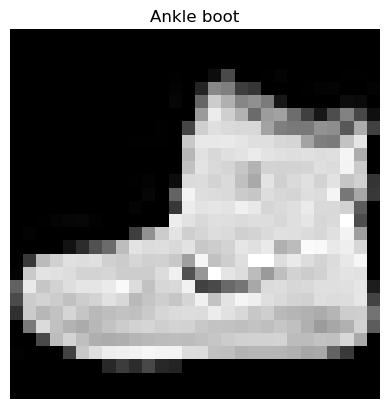

In [8]:
image, label = train_data[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label} ({class_names[label]})")

plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False);


The image has shape `[1, 28, 28]`, which means:

```text
[channels, height, width]
```

Since the image has only one channel, we display it using a grayscale color map with `cmap="gray"`.

Now let's visualize several random images from the training dataset.


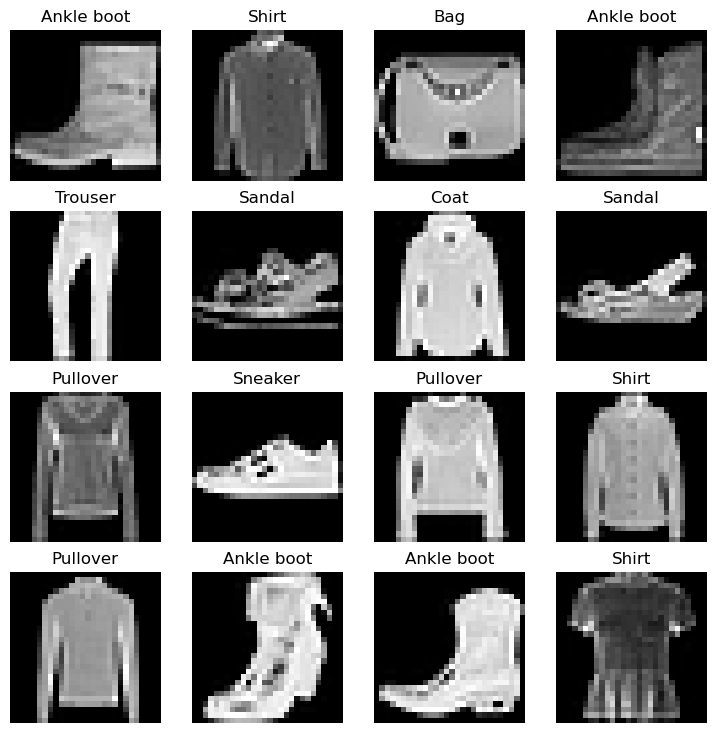

In [9]:
torch.manual_seed(42)

fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]

    fig.add_subplot(rows, cols, i)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

FashionMNIST images are small and not very detailed, but they are useful for learning the basic computer vision workflow.

The main idea is simple: we use pixel values as input and train a model to detect patterns that help predict the correct class.

Even though FashionMNIST contains 60,000 training images, it is still considered a relatively small dataset in deep learning. This makes it a good dataset for experimentation and learning.

## 2. Preparing DataLoaders

Now that we have loaded the dataset, the next step is to prepare it with [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

A `DataLoader` turns a PyTorch `Dataset` into an iterable object that returns smaller parts of the data called **batches** or **mini-batches**.

Instead of passing the entire dataset through the model at once, we train the model on one mini-batch at a time.

This is useful because:

* it is more memory-efficient;
* it allows the model to update its weights more often during each epoch;
* it is the standard approach for training deep learning models.

The number of samples in each batch is controlled by the `batch_size` parameter.

A common starting point is:


In [10]:
BATCH_SIZE = 32

Batch size is a **hyperparameter**, which means we choose it before training. Common values are powers of 2, such as `32`, `64`, `128`, or `256`.

![Batching FashionMNIST](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-batching-fashionmnist.png)

*Example of batching FashionMNIST images with a batch size of 32.*

Let's create `DataLoader` objects for the training and test datasets.


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Train DataLoader: {train_dataloader}")
print(f"Test DataLoader: {test_dataloader}")
print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")


Train DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x17fe286d0>
Test DataLoader: <torch.utils.data.dataloader.DataLoader object at 0x17fe6c890>
Number of training batches: 1875
Number of test batches: 313



Since FashionMNIST has 60,000 training images and we use a batch size of 32, the training `DataLoader` contains:


In [12]:
60000 / 32

1875.0


which gives 1,875 batches.

Now let's inspect one batch.


In [13]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))

print(f"Feature batch shape: {train_features_batch.shape}")
print(f"Label batch shape: {train_labels_batch.shape}")

Feature batch shape: torch.Size([32, 1, 28, 28])
Label batch shape: torch.Size([32])



This means:

```text
[batch_size, channels, height, width]
```

Now let's visualize one random image from the batch.


Image shape: torch.Size([1, 28, 28])
Label: 6 (Shirt)
Label shape: torch.Size([])


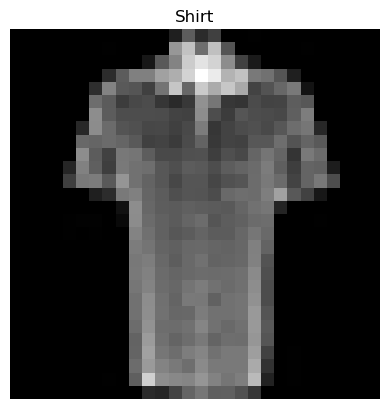

In [14]:
torch.manual_seed(42)

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()

img = train_features_batch[random_idx]
label = train_labels_batch[random_idx]

plt.imshow(img.squeeze().numpy(), cmap="gray")
plt.title(class_names[label])
plt.axis(False);

print(f"Image shape: {img.shape}")
print(f"Label: {label} ({class_names[label]})")
print(f"Label shape: {label.shape}")


## 3. Model 0: Building a Baseline Model

Our data is loaded and ready.

The first step is to build a **baseline model**.

A baseline model is a simple model that serves as a starting point. We use its performance as a reference and then try to improve upon it with more advanced architectures.

This baseline model will consist of:

1. A `nn.Flatten()` layer
2. Two `nn.Linear()` layers

### Why Do We Need `nn.Flatten()`?

Images are stored as multi-dimensional tensors.

For example, a FashionMNIST image has shape:

```text
[1, 28, 28]
```

where:

* `1` = channel
* `28` = height
* `28` = width

However, fully connected (`nn.Linear`) layers expect a vector as input.

To convert an image into a vector, we use `nn.Flatten()`.


In [15]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x)

print(f"Shape before flattening: {x.shape}")
print(f"Shape after flattening: {output.shape}")


Shape before flattening: torch.Size([1, 28, 28])
Shape after flattening: torch.Size([1, 784])



The flattening operation converts the image into a single feature vector containing all pixel values.

This allows us to pass the image through fully connected layers.

> **Note:** Flattening removes the spatial structure of the image. The model no longer knows which pixels are neighbors. Later, we will see how Convolutional Neural Networks (CNNs) preserve spatial information and typically achieve much better performance on image tasks.

Now let's build our first model.


In [16]:
from torch import nn

class FashionMNISTModelV0(nn.Module):
    def __init__(
        self,
        input_shape: int,
        hidden_units: int,
        output_shape: int
    ):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units
            ),
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape
            )
        )

    def forward(self, x):
        return self.layer_stack(x)



Next, we create an instance of the model.

The main parameters are:

* `input_shape=784` because each image contains `28 × 28 = 784` pixels.
* `hidden_units=10` to keep the model simple.
* `output_shape=len(class_names)` because we need one output neuron for each clothing category.


In [17]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)

model_0.to("cpu")

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

Our baseline model is now ready. In the next step, we will define a loss function and optimizer, then train it on the FashionMNIST dataset.


### 3.1 Setting Up the Loss Function, Optimizer, and Evaluation Metric

Before training our model, we need three key components:

1. A **loss function** to measure how far the predictions are from the true labels.
2. An **optimizer** to update the model parameters.
3. An **evaluation metric** to track performance.

For this multiclass classification problem, we will use:

* `nn.CrossEntropyLoss()` as the loss function.
* Stochastic Gradient Descent (`torch.optim.SGD`) as the optimizer.
* Classification accuracy as the evaluation metric.


In [18]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.1
)

> **Note:** We use a custom `accuracy_fn()` helper in this notebook. In real projects, it is common to use the `torchmetrics` package for evaluation metrics.


### 3.2 Measuring Training Time

Training speed is an important consideration when working with deep learning models.

To compare CPU and GPU performance later, let's create a small utility function that measures training time.



In [19]:
from timeit import default_timer as timer

def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
    """Print training time."""

    total_time = end - start

    print(f"Training time on {device}: {total_time:.3f} seconds")

    return total_time

### 3.3 Training the Baseline Model

Now that we have all the necessary components—a model, loss function, optimizer, DataLoaders, and a timer—we are ready to train our first model.

Recall that our data is loaded in mini-batches using `train_dataloader` and `test_dataloader`.

Since we are training on batches rather than the entire dataset at once:

* The model performs a forward and backward pass for each batch.
* The optimizer updates the model parameters after each batch.
* Loss and accuracy are accumulated across all batches and averaged at the end of each epoch.

The overall training process is:

1. Loop through the epochs.
2. Loop through the training batches and perform the training steps.
3. Loop through the test batches and evaluate the model.
4. Compute average metrics for the epoch.
5. Display the results.
6. Measure the total training time.


In [20]:
from tqdm.auto import tqdm

# Set random seed and start timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Number of training epochs
epochs = 3

# Training and evaluation loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")

    # ====================
    # Training
    # ====================
    train_loss = 0

    model_0.train()

    for batch, (X, y) in enumerate(train_dataloader):

        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Zero gradients
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Update model parameters
        optimizer.step()

        # Print progress occasionally
        if batch % 400 == 0:
            print(
                f"Processed {batch * len(X)}/"
                f"{len(train_dataloader.dataset)} samples"
            )

    # Average training loss for the epoch
    train_loss /= len(train_dataloader)

    # ====================
    # Evaluation
    # ====================
    test_loss = 0
    test_acc = 0

    model_0.eval()

    with torch.inference_mode():

        for X, y in test_dataloader:

            # 1. Forward pass
            test_pred = model_0(X)

            # 2. Calculate loss
            test_loss += loss_fn(test_pred, y).item()

            # 3. Calculate accuracy
            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

        # Average metrics across batches
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    # Print epoch results
    print(
        f"\nTrain loss: {train_loss:.5f} | "
        f"Test loss: {test_loss:.5f} | "
        f"Test accuracy: {test_acc:.2f}%\n"
    )

# Stop timer
train_time_end_on_cpu = timer()

# Calculate total training time
total_train_time_model_0 = print_train_time(
    start=train_time_start_on_cpu,
    end=train_time_end_on_cpu,
    device=str(next(model_0.parameters()).device)
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Processed 0/60000 samples
Processed 12800/60000 samples
Processed 25600/60000 samples
Processed 38400/60000 samples
Processed 51200/60000 samples


 33%|███▎      | 1/3 [00:01<00:03,  1.75s/it]


Train loss: 0.59039 | Test loss: 0.50954 | Test accuracy: 82.04%

Epoch: 1
-------
Processed 0/60000 samples
Processed 12800/60000 samples
Processed 25600/60000 samples
Processed 38400/60000 samples
Processed 51200/60000 samples


 67%|██████▋   | 2/3 [00:03<00:01,  1.56s/it]


Train loss: 0.47633 | Test loss: 0.47989 | Test accuracy: 83.20%

Epoch: 2
-------
Processed 0/60000 samples
Processed 12800/60000 samples
Processed 25600/60000 samples
Processed 38400/60000 samples
Processed 51200/60000 samples


100%|██████████| 3/3 [00:04<00:00,  1.55s/it]


Train loss: 0.45503 | Test loss: 0.47664 | Test accuracy: 83.43%

Training time on cpu: 4.665 seconds


The baseline model achieves reasonable performance despite its simplicity. However, it treats each image as a flattened vector and ignores the spatial relationships between pixels.

In the next sections, we will explore more advanced architectures that can capture these spatial patterns more effectively.


## 4. Evaluating Model 0

Since we will train and compare multiple models throughout this notebook, it is useful to create a reusable evaluation function.

The function below:

* takes a trained model,
* generates predictions for a given `DataLoader`,
* calculates the average loss,
* calculates the average accuracy,
* returns the results in a dictionary.

This will allow us to evaluate all future models in a consistent way.


In [21]:
torch.manual_seed(42)

def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn
):
    """Evaluate a model on a DataLoader."""

    loss = 0
    acc = 0

    model.eval()

    with torch.inference_mode():

        for X, y in data_loader:

            # Forward pass
            y_pred = model(X)

            # Calculate batch loss
            loss += loss_fn(y_pred, y).item()

            # Calculate batch accuracy
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )

    # Average metrics across batches
    loss /= len(data_loader)
    acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }


Now let's evaluate our baseline model on the test dataset.

In [22]:
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

model_0_results


{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663889187402997,
 'model_acc': 83.42651757188499}

The returned dictionary provides a convenient way to store and compare results from different models. As we build more advanced architectures later in the notebook, we will use this function to track whether our changes improve performance.

## 5. Writing Device-Agnostic Code

So far, our baseline model has been trained on the CPU.

Training time depends heavily on the hardware being used. Larger models and larger datasets usually benefit from faster accelerators such as GPUs.

To make our code more flexible, we can write **device-agnostic code**. This means the same notebook can run on different hardware without major changes.


In [23]:
import torch

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

device

'mps'

This code selects:

* `"cuda"` if an NVIDIA GPU is available,
* `"mps"` if Apple Silicon acceleration is available,
* `"cpu"` otherwise.

When training models, both the model and the data must be moved to the same device.


This will become important in the next model, where we train using the selected device.



## 6. Model 1: Adding Non-Linearity

In previous lessons, we discussed that neural networks use non-linear functions to learn more complex patterns in data.

Our baseline model only used linear layers. Now we will add a non-linear activation function, `nn.ReLU()`, between the linear layers.

This gives the model more flexibility to learn non-linear relationships.


In [24]:
class FashionMNISTModelV1(nn.Module):
    def __init__(
        self,
        input_shape: int,
        hidden_units: int,
        output_shape: int
    ):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=input_shape,
                out_features=hidden_units
            ),
            nn.ReLU(),
            nn.Linear(
                in_features=hidden_units,
                out_features=output_shape
            )
        )

    def forward(self, x: torch.Tensor):
        return self.layer_stack(x)


Notice that we changed only one thing compared to the baseline model: we added a non-linear activation function.

This is a useful experimentation strategy in machine learning:

> Change one thing, measure the result, then repeat.

Now let's create the model using the same settings as before:

* `input_shape=784`, because each image has `28 × 28 = 784` pixels.
* `hidden_units=10`, to keep the model small.
* `output_shape=len(class_names)`, because we need one output value for each class.


> We do not apply ReLU or Softmax after the final layer. CrossEntropyLoss expects raw logits as input.

In [25]:
torch.manual_seed(42)

model_1 = FashionMNISTModelV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

next(model_1.parameters()).device

device(type='mps', index=0)

### 6.1 Setting Up the Loss Function, Optimizer, and Evaluation Metric

As before, we need a loss function, an optimizer, and an evaluation metric.

For this multiclass classification task, we will use `CrossEntropyLoss`, SGD, and accuracy.


In [26]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    params=model_1.parameters(),
    lr=0.1
)


### 6.2 Functionalizing Training and Testing Loops

So far, we have written the training and testing loops directly in the notebook.

Since we will train multiple models, it is better to turn these loops into reusable functions.

We will create:

* `train_step()` for one training epoch.
* `test_step()` for one evaluation epoch.

Because we are now using device-agnostic code, we also move both the model and the data to the selected device.


In [27]:
def train_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device
):
    """Performs one training epoch."""

    train_loss = 0
    train_acc = 0

    model.to(device)
    model.train()

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss and accuracy
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(
            y_true=y,
            y_pred=y_pred.argmax(dim=1)
        )

        # 3. Zero gradients
        optimizer.zero_grad()

        # 4. Backpropagation
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Average metrics across batches
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")


def test_step(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device
):
    """Performs one evaluation epoch."""

    test_loss = 0
    test_acc = 0

    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(
                y_true=y,
                y_pred=test_pred.argmax(dim=1)
            )

    # Average metrics across batches
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")


These functions make the notebook cleaner and allow us to train future models using the same training and evaluation logic.


Great! Now that we have reusable training and testing functions, let's train `model_1`.

For each epoch, we will run:

1. `train_step()` to update the model parameters.
2. `test_step()` to evaluate the model on the test data.

> **Note:** In this notebook, we evaluate the model after every epoch. In larger projects, evaluation may be done less often, for example every 5 or 10 epochs.


In [28]:
torch.manual_seed(42)

from timeit import default_timer as timer

train_time_start_on_gpu = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")

    train_step(
        model=model_1,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_1,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_train_time(
    start=train_time_start_on_gpu,
    end=train_time_end_on_gpu,
    device=device
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.64607 | Train accuracy: 77.17%


 33%|███▎      | 1/3 [00:05<00:10,  5.17s/it]

Test loss: 0.53855 | Test accuracy: 80.76%

Epoch: 1
---------
Train loss: 0.48094 | Train accuracy: 82.94%


 67%|██████▋   | 2/3 [00:09<00:04,  4.84s/it]

Test loss: 0.49390 | Test accuracy: 82.46%

Epoch: 2
---------
Train loss: 0.44689 | Train accuracy: 84.16%


100%|██████████| 3/3 [00:14<00:00,  4.88s/it]

Test loss: 0.45746 | Test accuracy: 83.99%

Training time on mps: 14.626 seconds


Our model has now been trained using device-agnostic code.

Depending on your hardware, this may or may not be faster than CPU training.

For small models and small datasets like FashionMNIST, GPU training is not always faster. This is because moving data from CPU memory to GPU memory also takes time.

For larger models and larger datasets, the GPU usually becomes much more useful because its parallel computation power outweighs the data transfer cost.

Next, let's evaluate the trained `model_1` using our reusable `eval_model()` function.


If we try to evaluate `model_1` using the previous version of `eval_model()`, we may get a device mismatch error.


In [29]:
torch.manual_seed(42)

# This may raise an error because the old eval_model()
# does not move data to the same device as the model.
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

model_1_results

RuntimeError: Placeholder storage has not been allocated on MPS device!


The error may look like this:

```text
RuntimeError: Expected all tensors to be on the same device, but found at least two devices...
```

This happens because the model is on the selected device, such as `"cuda"` or `"mps"`, while the data is still on the CPU.

To fix this, we update `eval_model()` so it also moves `X` and `y` to the target device.


In [30]:
torch.manual_seed(42)

def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn,
    device: torch.device = device
):
    """Evaluate a model on a DataLoader using device-agnostic code."""

    loss = 0
    acc = 0

    model.to(device)
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # Forward pass
            y_pred = model(X)

            # Calculate loss and accuracy
            loss += loss_fn(y_pred, y).item()
            acc += accuracy_fn(
                y_true=y,
                y_pred=y_pred.argmax(dim=1)
            )

    # Average metrics across batches
    loss /= len(data_loader)
    acc /= len(data_loader)

    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss,
        "model_acc": acc
    }


Now we can evaluate `model_1` correctly.

In [31]:
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

model_1_results

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.4574634959808173,
 'model_acc': 83.98562300319489}

This version works because the model and the data are now placed on the same device.

The results show a small improvement over our baseline model.

| Model                   | Test Loss | Test Accuracy |
| ----------------------- | --------- | ------------- |
| Model 0 (Linear)        | 0.4766    | 83.43%        |
| Model 1 (Linear + ReLU) | 0.4575    | 83.99%        |

Although the improvement is modest, it demonstrates an important concept in deep learning:

> Adding non-linearity allows neural networks to learn more complex patterns than purely linear models.

Without activation functions such as `ReLU`, stacking multiple linear layers is mathematically equivalent to a single linear transformation. By introducing non-linearity, the model gains the ability to represent more complex decision boundaries.

However, the improvement is relatively small. This suggests that simply adding a non-linear activation function is not enough to fully capture the structure of image data.

The main limitation of both Model 0 and Model 1 is that they flatten each image into a one-dimensional vector before processing it. As a result, the models lose information about the spatial relationships between neighboring pixels.

To address this limitation, we need an architecture specifically designed for images.

This brings us to one of the most important model families in computer vision: **Convolutional Neural Networks (CNNs)**.


## 7. Model 2: Building a Convolutional Neural Network (CNN)

Our previous models treated each image as a flattened vector of pixels.

While this approach can work, it ignores the spatial relationships between neighboring pixels.

To better capture image structure, we will now build a **[Convolutional Neural Network (CNN)](https://en.wikipedia.org/wiki/Convolutional_neural_network)**.

CNNs are specifically designed for visual data and have been one of the most influential architectures in computer vision.

Unlike fully connected networks, CNNs learn local patterns such as:

* edges,
* corners,
* textures,
* shapes,

and combine them into higher-level visual features.

Since FashionMNIST is an image classification task, a CNN should be able to make better use of the image information than our previous models.

In this notebook, we will implement a simplified version of **TinyVGG**, a small CNN architecture inspired by the model presented in the [CNN Explainer project](https://poloclub.github.io/cnn-explainer/).

A typical CNN follows a structure similar to:

```text
Input
    ↓
[Convolution → Activation → Pooling]
    ↓
[Convolution → Activation → Pooling]
    ↓
Classifier
    ↓
Output
```

The convolution and pooling blocks can be repeated multiple times depending on the complexity of the problem.



### Choosing a Model for Different Types of Data

Different data types often benefit from different model families.

| Problem Type                           | Common Models                              |
| -------------------------------------- | ------------------------------------------ |
| Structured data (tables, spreadsheets) | Gradient Boosting, Random Forests, XGBoost |
| Images                                 | CNNs, Vision Transformers (ViTs)           |
| Text                                   | Transformers                               |
| Audio                                  | CNNs, Transformers                         |

> **Note:** These are general guidelines rather than strict rules. The best model depends on the dataset, computational resources, latency requirements, and many other factors.

The TinyVGG architecture we will build is shown below.

![TinyVGG architecture](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-cnn-explainer-model.png)

To implement it, we will use two key PyTorch layers:

* [`nn.Conv2d()`](https://docs.pytorch.org/docs/2.12/generated/torch.nn.Conv2d.html) for learning visual features,
* [`nn.MaxPool2d()`](https://docs.pytorch.org/docs/2.12/generated/torch.nn.MaxPool2d.html) for reducing spatial dimensions and computation.


In [32]:
class FashionMNISTModelV2(nn.Module):
    """
    TinyVGG-inspired CNN architecture.
    """

    def __init__(
        self,
        input_shape: int,
        hidden_units: int,
        output_shape: int
    ):
        super().__init__()

        self.block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self.block_2 = nn.Sequential(
            nn.Conv2d(
                hidden_units,
                hidden_units,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                hidden_units,
                hidden_units,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=hidden_units * 7 * 7,
                out_features=output_shape
            )
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)

        return x



Let's create an instance of the model.


In [33]:
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
).to(device)

model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


### Why is `in_features = hidden_units * 7 * 7`?

This value comes from the spatial dimensions of the feature maps after the convolution and pooling blocks.

The input image has shape:

```text
[1, 28, 28]
```

After the first `MaxPool2d(2)`:

```text
[10, 14, 14]
```

After the second `MaxPool2d(2)`:

```text
[10, 7, 7]
```

When we flatten this tensor, we get:

```text
10 × 7 × 7 = 490
```

features.

Therefore:

```python
nn.Linear(
    in_features=10 * 7 * 7,
    out_features=output_shape
)
```

or more generally:

```python
hidden_units * 7 * 7
```

which allows the architecture to adapt automatically when `hidden_units` changes.


### 7.1 Understanding `nn.Conv2d()`

Before training our CNN, let's take a closer look at one of its most important layers: `nn.Conv2d()`.

A convolutional layer learns small filters, also called **kernels**, that move across an image and detect local patterns such as edges, curves, and textures.

In PyTorch, `nn.Conv2d()` is used for image-like data with height and width dimensions.

The main parameters are:

* `in_channels` – number of input channels.
* `out_channels` – number of filters the layer learns.
* `kernel_size` – size of each filter.
* `stride` – how far the filter moves at each step.
* `padding` – how much empty space is added around the image borders.

For FashionMNIST, each image has one channel:

```text
[1, 28, 28]
```

For RGB images, we usually have three channels:

```text
[3, height, width]
```

Let's create some toy image data to understand how convolution changes tensor shapes.


In [34]:
torch.manual_seed(42)

images = torch.randn(size=(32, 3, 64, 64))

test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])



The batch has shape:

```text
[batch_size, channels, height, width]
```

or:

```text
[32, 3, 64, 64]
```

Now let's create a convolutional layer.



In [35]:
torch.manual_seed(42)

conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=3,
    stride=1,
    padding=0
)


Passing one image through the layer:

In [36]:
conv_output = conv_layer(test_image)

conv_output.shape

torch.Size([10, 62, 62])


The output shape is:

```text
[10, 62, 62]
```

This means the convolutional layer transformed the image from:

```text
[3, 64, 64]
```

to:

```text
[10, 62, 62]
```

The number of channels changed from `3` to `10` because we set:

```python
out_channels=10
```

The height and width became smaller because we used:

```python
kernel_size=3
padding=0
```

Without padding, the convolution cannot be applied at the borders in a way that preserves the original image size.

If we want to include a batch dimension, we can use `unsqueeze(dim=0)`:



In [37]:
test_image_with_batch = test_image.unsqueeze(dim=0)

print(test_image_with_batch.shape)

torch.Size([1, 3, 64, 64])



Now the tensor has the standard CNN format:

```text
[batch_size, channels, height, width]
```

Passing it through the same convolutional layer gives:


In [38]:
conv_output = conv_layer(test_image_with_batch)

conv_output.shape

torch.Size([1, 10, 62, 62])

Now let's try another convolutional layer with different parameters.


In [39]:
torch.manual_seed(42)

conv_layer_2 = nn.Conv2d(
    in_channels=3,
    out_channels=10,
    kernel_size=5,
    stride=2,
    padding=0
)

conv_layer_2(test_image_with_batch).shape


torch.Size([1, 10, 30, 30])


This output is smaller because:

* `kernel_size=5` uses a larger filter;
* `stride=2` moves the filter two pixels at a time;
* `padding=0` does not preserve the border size.

Behind the scenes, the convolutional layer contains trainable weights and biases.


In [40]:
print(f"Weight shape: {conv_layer_2.weight.shape}")
print(f"Bias shape: {conv_layer_2.bias.shape}")

Weight shape: torch.Size([10, 3, 5, 5])
Bias shape: torch.Size([10])


The weight shape can be read as:

```text
[out_channels, in_channels, kernel_height, kernel_width]
```

or:

```text
[10, 3, 5, 5]
```

This means the layer learns `10` filters, and each filter looks at all `3` input channels using a `5 × 5` kernel.

The main idea is the same as before: the layer starts with random weights and learns better values during training.

The difference is that convolutional layers learn local spatial patterns instead of treating every pixel independently.

### 7.2 Understanding `nn.MaxPool2d()`

Another important layer in CNNs is `nn.MaxPool2d()`.

The purpose of max pooling is to reduce the spatial dimensions of a feature map while retaining the most important information.

Let's see how it affects tensor shapes.


In [41]:
print(f"Original image shape: {test_image.shape}")
print(f"Image with batch dimension: {test_image.unsqueeze(dim=0).shape}")

max_pool_layer = nn.MaxPool2d(kernel_size=2)

test_image_through_conv = conv_layer(
    test_image.unsqueeze(dim=0)
)

print(
    f"Shape after Conv2d: "
    f"{test_image_through_conv.shape}"
)

test_image_through_conv_and_max_pool = max_pool_layer(
    test_image_through_conv
)

print(
    f"Shape after Conv2d + MaxPool2d: "
    f"{test_image_through_conv_and_max_pool.shape}"
)

Original image shape: torch.Size([3, 64, 64])
Image with batch dimension: torch.Size([1, 3, 64, 64])
Shape after Conv2d: torch.Size([1, 10, 62, 62])
Shape after Conv2d + MaxPool2d: torch.Size([1, 10, 31, 31])



Notice what happened:

```text
[1, 10, 62, 62]
    ↓
[1, 10, 31, 31]
```

The height and width were reduced by half.

This happens because we used:

```python
nn.MaxPool2d(kernel_size=2)
```

which looks at each `2 × 2` region and keeps only the largest value.

Let's see a simple example.


In [42]:
torch.manual_seed(42)

random_tensor = torch.randn(size=(1, 1, 2, 2))

print(random_tensor)
print(random_tensor.shape)

max_pool_layer = nn.MaxPool2d(kernel_size=2)

max_pool_tensor = max_pool_layer(random_tensor)

print("\nMax pooled tensor:")
print(max_pool_tensor)
print(max_pool_tensor.shape)


tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
torch.Size([1, 1, 2, 2])

Max pooled tensor:
tensor([[[[0.3367]]]])
torch.Size([1, 1, 1, 1])



The input shape:

```text
[1, 1, 2, 2]
```

becomes:

```text
[1, 1, 1, 1]
```

because the pooling layer selects the largest value from the entire `2 × 2` region.



### Why Use Max Pooling?

Max pooling serves two main purposes:

1. **Reduce computation**

   * Smaller feature maps require fewer calculations in later layers.

2. **Keep important features**

   * Strong activations often correspond to meaningful visual patterns such as edges, corners, or textures.

As information flows through a CNN, the network gradually transforms the image into increasingly compact feature representations.

![CNN compression intuition](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv-net-as-compression.png)

Convolutional layers learn useful visual features, while pooling layers reduce spatial resolution and help the network focus on the most important information.

> **Exercise:** What do you think `nn.AvgPool2d()` does? Create a random tensor, pass it through the layer, and compare the input and output values.

> **Further exploration:** Search for popular CNN architectures such as LeNet, AlexNet, VGG, ResNet, EfficientNet, and DenseNet. How many of them are available in [`torchvision.models`](https://docs.pytorch.org/vision/stable/models.html)?


In [43]:
torch.manual_seed(42)

random_tensor = torch.randn(size=(1, 1, 2, 2))

print(random_tensor)
print(random_tensor.shape)

avg_pool_layer = nn.AvgPool2d(kernel_size=2)

avg_pool_tensor = avg_pool_layer(random_tensor)

print("\nAvg pooled tensor:")
print(avg_pool_tensor)
print(avg_pool_tensor.shape)


tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
torch.Size([1, 1, 2, 2])

Avg pooled tensor:
tensor([[[[0.2326]]]])
torch.Size([1, 1, 1, 1])


### 7.3 Setting Up the Loss Function and Optimizer for `model_2`

Now that we have defined our CNN, we can prepare it for training.

As before, we will use:

* `nn.CrossEntropyLoss()` for multiclass classification.
* `torch.optim.SGD()` to update the model parameters.


In [44]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr=0.1
)

The setup is the same as before, but now the optimizer will update the parameters of our CNN model.

> Even though the architecture changed, the training setup remains mostly the same: forward pass, loss calculation, backpropagation, and optimizer step.



### 7.4 Training and Evaluating `model_2`

Our loss function and optimizer are ready.

Now let's train the CNN using the same `train_step()` and `test_step()` functions that we created earlier.

We will also measure the training time so that we can compare it with our previous models.


In [45]:
torch.manual_seed(42)

from timeit import default_timer as timer

train_time_start_model_2 = timer()

epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")

    train_step(
        model=model_2,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )

    test_step(
        model=model_2,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(
    start=train_time_start_model_2,
    end=train_time_end_model_2,
    device=device
)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.59166 | Train accuracy: 78.49%


 33%|███▎      | 1/3 [00:09<00:19,  9.71s/it]

Test loss: 0.39617 | Test accuracy: 85.72%

Epoch: 1
---------
Train loss: 0.36768 | Train accuracy: 86.69%


 67%|██████▋   | 2/3 [00:18<00:09,  9.02s/it]

Test loss: 0.35426 | Test accuracy: 86.92%

Epoch: 2
---------
Train loss: 0.32993 | Train accuracy: 87.92%


100%|██████████| 3/3 [00:26<00:00,  8.95s/it]

Test loss: 0.32604 | Test accuracy: 87.96%

Training time on mps: 26.858 seconds


Now let's evaluate `model_2` using our reusable `eval_model()` function and compare its performance with the previous models.


In [46]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3260429094012934,
 'model_acc': 87.95926517571885}

The CNN achieved the best performance so far.

| Model                   | Test Loss | Test Accuracy |
| ----------------------- | --------- | ------------- |
| Model 0 (Linear)        | 0.4766    | 83.43%        |
| Model 1 (Linear + ReLU) | 0.4575    | 83.99%        |
| Model 2 (CNN)           | 0.3260    | 87.96%        |

This is a much larger improvement than the one we observed when simply adding a non-linear activation function.

Why did the CNN perform better?

The key difference is that convolutional layers preserve and exploit the spatial structure of images.

Our previous models flattened each image into a one-dimensional vector:

```text
[1, 28, 28]
    ↓
[784]
```

As a result, neighboring pixels lost their spatial relationships.

CNNs process images differently. Convolutional filters examine local regions of the image and learn useful visual patterns such as:

* edges,
* corners,
* textures,
* simple shapes.

These low-level patterns are then combined into more complex visual features in deeper layers.

This ability to learn hierarchical visual representations is one of the main reasons CNNs have been so successful in computer vision.

Although our TinyVGG model is relatively small, it already demonstrates an important lesson:

> Architectures designed specifically for image data often outperform generic fully connected networks on computer vision tasks.


## 8. Comparing Model Results and Training Time

We trained three different models:

1. `model_0` — a baseline model with two `nn.Linear()` layers.
2. `model_1` — a similar model, but with `nn.ReLU()` added between the linear layers.
3. `model_2` — a CNN inspired by the TinyVGG architecture.

This is a common workflow in machine learning: build several models, run experiments, compare results, and choose the best approach based on the target metric.

Let's combine the results into a single DataFrame.


In [50]:
import pandas as pd

compare_results = pd.DataFrame([
    model_0_results,
    model_1_results,
    model_2_results
])

compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.457463,83.985623
2,FashionMNISTModelV2,0.326043,87.959265


Now let's add training time for each model.

In [51]:
compare_results["training_time"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2
]

compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,4.665236
1,FashionMNISTModelV1,0.457463,83.985623,14.626382
2,FashionMNISTModelV2,0.326043,87.959265,26.857545



Based on our results, the CNN model (`FashionMNISTModelV2`) achieved the best performance: the lowest test loss and the highest test accuracy.

`model_1` also slightly improved over the baseline, which shows that adding non-linearity helped, although only modestly.



### Performance vs. Speed Trade-Off

In machine learning, there is often a trade-off between **model performance** and **training speed**.

More complex models may achieve better accuracy, but they can also take longer to train and run during inference.

In our case, the CNN performs best because it is better suited for image data. It preserves spatial structure and learns local visual patterns using convolutional layers.

However, training time depends heavily on your hardware. CPU, CUDA GPU, and Apple Silicon MPS can all produce different timing results.

Let's visualize the model accuracies.


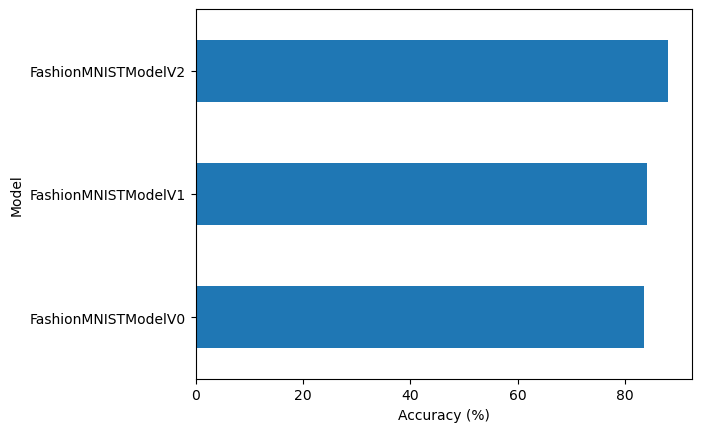

In [52]:
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")

plt.xlabel("Accuracy (%)")
plt.ylabel("Model");


### Comparing the Number of Parameters

An interesting observation is that the CNN can achieve better accuracy while using fewer parameters than the fully connected models.

This happens because convolutional layers reuse small filters across the image. This is called **weight sharing**.

Instead of learning a separate weight for every input pixel connection, CNNs learn compact filters that scan across the image.

Let's count the number of parameters in each model.


In [53]:
def count_model_parameters(model: torch.nn.Module):
    """Count total and trainable parameters in a PyTorch model."""

    total_params = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_params = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")

    return {
        "total_params": total_params,
        "trainable_params": trainable_params
    }

In [54]:
model_0_params = count_model_parameters(model_0)

Total parameters: 7960
Trainable parameters: 7960


In [55]:
model_1_params = count_model_parameters(model_1)

Total parameters: 7960
Trainable parameters: 7960


In [56]:
model_2_params = count_model_parameters(model_2)

Total parameters: 7740
Trainable parameters: 7740


The CNN has fewer parameters, but it performs better because its architecture matches the structure of image data.


In [57]:
compare_results["parameters"] = [
    model_0_params["total_params"],
    model_1_params["total_params"],
    model_2_params["total_params"]
]

compare_results


,model_name,model_loss,model_acc,training_time,parameters
0,FashionMNISTModelV0,0.476639,83.426518,4.665236,7960
1,FashionMNISTModelV1,0.457463,83.985623,14.626382,7960
2,FashionMNISTModelV2,0.326043,87.959265,26.857545,7740


### Why Does the CNN Have Fewer Parameters?

Let's compare the total number of trainable parameters in each model:

| Model                   | Parameters |
| ----------------------- | ---------: |
| Model 0 (Linear)        |      7,960 |
| Model 1 (Linear + ReLU) |      7,960 |
| Model 2 (CNN)           |      7,740 |

Although the CNN achieves the best accuracy, it actually has fewer parameters than the fully connected models.

This happens because CNNs use **weight sharing**. Instead of learning a separate weight for every pixel connection, convolutional layers learn small filters (e.g. `3×3`) and reuse them across the entire image.

For example, the first convolutional layer contains:

```text
10 × (1 × 3 × 3) + 10 biases = 100 parameters
```

while the first linear layer in Model 0 contains:

```text
784 × 10 + 10 biases = 7,850 parameters
```

By reusing the same filters across different image locations, CNNs can learn meaningful visual patterns with far fewer parameters, which often leads to better performance on image tasks.


## 9. Making and Evaluating Random Predictions with the Best Model

We have compared all three models. Now let's take a closer look at the best-performing model, `model_2`.

To do this, we will create a helper function called `make_predictions()`.

This function will:

1. take a model and a list of images,
2. make predictions for each image,
3. convert logits into probabilities using `softmax`,
4. return the prediction probabilities.


In [58]:
def make_predictions(
    model: torch.nn.Module,
    data: list,
    device: torch.device = device
):
    """Make predictions on a list of image tensors."""

    pred_probs = []

    model.to(device)
    model.eval()

    with torch.inference_mode():
        for sample in data:
            # Add batch dimension and move sample to target device
            sample = sample.unsqueeze(dim=0).to(device)

            # Forward pass: raw logits
            pred_logit = model(sample)

            # Convert logits to prediction probabilities
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

            # Move probabilities back to CPU
            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)


Now let's randomly select a few samples from the test dataset.


In [59]:
import random

random.seed(42)

test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

print(
    f"Test sample image shape: {test_samples[0].shape}\n"
    f"Test sample label: {test_labels[0]} ({class_names[test_labels[0]]})"
)


Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


Next, we use `model_2` to predict the classes of these images.


In [60]:
pred_probs = make_predictions(
    model=model_2,
    data=test_samples,
    device=device
)

pred_probs[:2]


tensor([[5.8249e-08, 2.5707e-09, 1.8736e-08, 2.1719e-07, 4.7056e-10, 9.9998e-01,
         2.3244e-08, 7.7235e-06, 4.0267e-06, 5.4134e-06],
        [5.6719e-02, 6.9931e-01, 1.0223e-03, 6.7623e-02, 5.1500e-02, 6.6496e-05,
         1.2250e-01, 2.4703e-04, 8.5159e-04, 1.6021e-04]])


The model returns probabilities for each class.

To get the predicted class label, we take the index of the highest probability using `argmax()`.



In [61]:
pred_classes = pred_probs.argmax(dim=1)

pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

Now we can compare the predicted classes with the true labels.


In [62]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1], tensor([5, 1, 7, 4, 3, 0, 4, 7, 1]))

Finally, let's visualize the predictions.

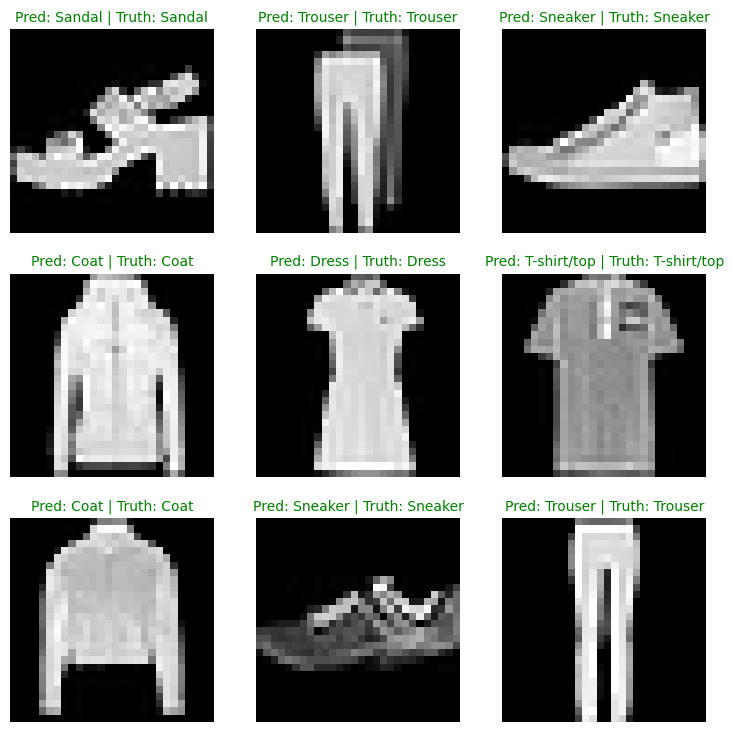

In [63]:
plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):

    plt.subplot(nrows, ncols, i + 1)

    plt.imshow(sample.squeeze().numpy(), cmap="gray")

    pred_label = class_names[pred_classes[i]]
    truth_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    if pred_label == truth_label:
        plt.title(title_text, fontsize=10, c="g")
    else:
        plt.title(title_text, fontsize=10, c="r")

    plt.axis(False)


Green titles indicate correct predictions, while red titles indicate incorrect predictions.

This visual check helps us understand not only the model's accuracy, but also the types of images it may still confuse.


### Correct vs. Wrong Predictions

In the previous visualization, we randomly selected 9 test images and all of them were predicted correctly.

This can happen by chance, especially when the model has relatively high accuracy. To better understand where the model struggles, let's intentionally search for misclassified examples.


In [67]:
correct_examples = []
wrong_examples = []

model_2.eval()

with torch.inference_mode():
    for image, label in test_data:
        image_batch = image.unsqueeze(dim=0).to(device)

        pred_logit = model_2(image_batch)
        pred_label = pred_logit.argmax(dim=1).item()

        if pred_label == label and len(correct_examples) < 4:
            correct_examples.append((image, pred_label, label))

        if pred_label != label and len(wrong_examples) < 5:
            wrong_examples.append((image, pred_label, label))

        if len(correct_examples) == 4 and len(wrong_examples) == 5:
            break

Now let's combine correct and wrong examples and visualize them.


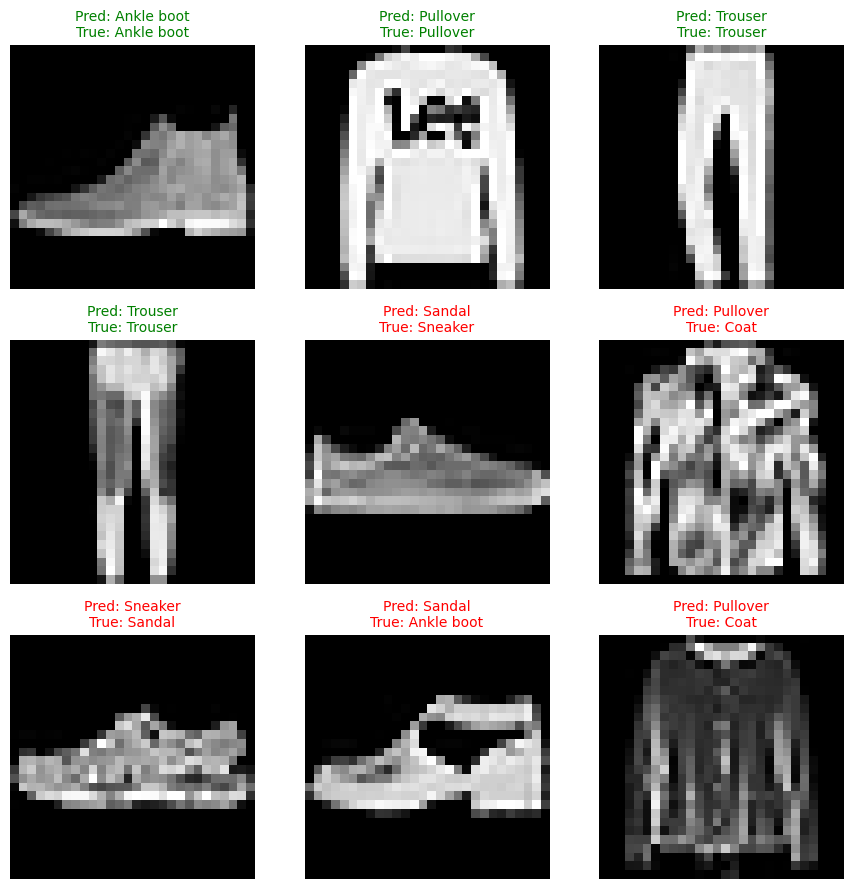

In [68]:
examples = correct_examples + wrong_examples

plt.figure(figsize=(9, 9))

for i, (image, pred_label, true_label) in enumerate(examples):
    plt.subplot(3, 3, i + 1)

    plt.imshow(image.squeeze().numpy(), cmap="gray")

    pred_name = class_names[pred_label]
    true_name = class_names[true_label]

    title_color = "green" if pred_label == true_label else "red"

    plt.title(
        f"Pred: {pred_name}\nTrue: {true_name}",
        color=title_color,
        fontsize=10
    )

    plt.axis(False)

plt.tight_layout()

Green titles show correct predictions, while red titles show mistakes.

Looking at wrong predictions is often more useful than only looking at accuracy, because it helps us understand what types of images the model confuses.


## 10. Creating a Confusion Matrix

Accuracy tells us how often the model is correct, but it does not show **which classes the model confuses**.

A **confusion matrix** compares predicted labels with true labels and helps us see where the model makes mistakes.

First, let's collect predictions for the entire test dataset.


In [69]:
from tqdm.auto import tqdm

y_preds = []

model_2.eval()

with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X = X.to(device)

        y_logits = model_2(X)
        y_pred = y_logits.argmax(dim=1)

        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)


Making predictions: 100%|██████████| 313/313 [00:00<00:00, 460.19it/s]


Now let's build and plot the confusion matrix using `scikit-learn`.


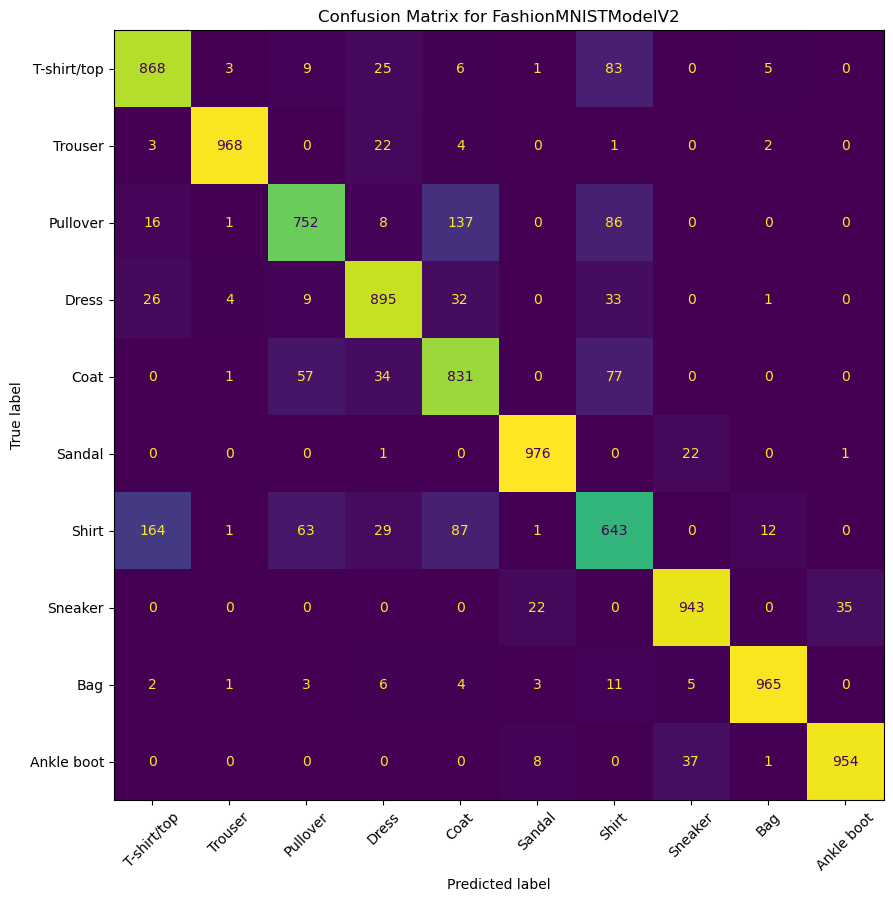

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

confmat = confusion_matrix(
    y_true=test_data.targets,
    y_pred=y_pred_tensor
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confmat,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))

display.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title("Confusion Matrix for FashionMNISTModelV2")
plt.show()


The diagonal values show correct predictions.

Values outside the diagonal show mistakes. For example, if the model predicts `"Shirt"` when the true label is `"T-shirt/top"`, that mistake appears outside the diagonal.

This gives us more information than accuracy alone because it shows **where** the model is confused.

For FashionMNIST, mistakes between visually similar classes are expected. For example:

* `Shirt` vs. `T-shirt/top`
* `Pullover` vs. `Coat`
* `Sandal` vs. `Sneaker`

This helps us understand whether the model needs improvement, or whether some classes are simply visually similar.


## 11. Saving and Loading the Best Model

To finish this notebook, let's save and reload our best model, `model_2`.

In PyTorch, the common workflow is:

* `torch.save()` — saves a model object or a model `state_dict`.
* `torch.load()` — loads a saved PyTorch object.
* `model.load_state_dict()` — loads saved parameters into an existing model instance.

A common best practice is to save only the model's `state_dict`, which contains the learned parameters.


In [71]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_NAME = "pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")

torch.save(
    obj=model_2.state_dict(),
    f=MODEL_SAVE_PATH
)


Saving model to: models/pytorch_computer_vision_model_2.pth


Now let's load the saved model.

Since we saved only the `state_dict`, we first need to create a new instance of the same model architecture.

The architecture must match the saved model exactly.


In [72]:
loaded_model_2 = FashionMNISTModelV2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(class_names)
)

loaded_model_2.load_state_dict(
    torch.load(
        f=MODEL_SAVE_PATH,
        map_location=device
    )
)

loaded_model_2 = loaded_model_2.to(device)


Now let's evaluate the loaded model and check whether it gives the same results as the original model.


In [73]:
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

loaded_model_2_results

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3260429094012934,
 'model_acc': 87.95926517571885}

The loaded model should produce the same, or almost the same, results as `model_2`.

We can verify this by comparing the losses.

In [74]:
torch.isclose(
    torch.tensor(model_2_results["model_loss"]),
    torch.tensor(loaded_model_2_results["model_loss"]),
    atol=1e-08,
    rtol=0.0001
)

tensor(True)

This confirms that the model was saved and loaded successfully.

## Conclusion

In this notebook, we built our first end-to-end computer vision pipeline using PyTorch and the FashionMNIST dataset.

We learned how to:

* Load and explore image datasets with `torchvision.datasets`.
* Prepare data using `DataLoader` and mini-batches.
* Understand image tensor shapes (`CHW` / `NCHW`).
* Build and train a baseline fully connected neural network.
* Add non-linear activation functions and compare model performance.
* Use device-independent code to leverage GPU acceleration when available.
* Build a Convolutional Neural Network (CNN) using `nn.Conv2d` and `nn.MaxPool2d`.
* Understand how convolution and pooling layers transform image representations.
* Evaluate models using accuracy, loss, and confusion matrices.
* Visualize both correct and incorrect predictions.
* Save and load trained PyTorch models.

Most importantly, we observed that the CNN achieved the best performance on FashionMNIST while using fewer parameters than the fully connected models. This highlights one of the key strengths of CNNs: they exploit the spatial structure of images through local filters and weight sharing, making them both efficient and effective for computer vision tasks.

The concepts introduced here form the foundation for more advanced computer vision architectures and tasks, including transfer learning, object detection, image segmentation, and modern vision transformers.
